# Correlation Analysis: Sentiment Scores vs Stock Returns

This notebook calculates the Pearson correlation coefficient between average daily sentiment scores and daily stock returns for various tech stocks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from datetime import datetime
import os

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Data

In [2]:
# Define the stocks we're analyzing
stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

# Load sentiment analysis data
sentiment_data = {}
for stock in stocks:
    try:
        sentiment_file = f'../../../data/sentiment_analysis_{stock}.csv'
        sentiment_data[stock] = pd.read_csv(sentiment_file)
        print(f"Loaded sentiment data for {stock}: {len(sentiment_data[stock])} records")
    except FileNotFoundError:
        print(f"Warning: Sentiment file not found for {stock}")

# Load daily returns data
returns_data = {}
for stock in stocks:
    try:
        returns_file = f'../../../data/daily_returns/{stock}_daily_returns.csv'
        returns_data[stock] = pd.read_csv(returns_file)
        print(f"Loaded returns data for {stock}: {len(returns_data[stock])} records")
    except FileNotFoundError:
        print(f"Warning: Returns file not found for {stock}")

Loaded sentiment data for AAPL: 441 records
Loaded sentiment data for AMZN: 278 records
Loaded sentiment data for GOOG: 1199 records
Loaded sentiment data for META: 380 records
Loaded sentiment data for NVDA: 3146 records
Loaded returns data for AAPL: 3774 records
Loaded returns data for AMZN: 3774 records
Loaded returns data for GOOG: 3774 records
Loaded returns data for META: 2923 records
Loaded returns data for NVDA: 3774 records


## Explore Data Structure

In [3]:
# Display sample data and structure
for stock in stocks:
    if stock in sentiment_data:
        print(f"\n=== {stock} Sentiment Data ===")
        print(f"Columns: {list(sentiment_data[stock].columns)}")
        print(f"Shape: {sentiment_data[stock].shape}")
        print("Sample:")
        print(sentiment_data[stock].head(2))
        
    if stock in returns_data:
        print(f"\n=== {stock} Returns Data ===")
        print(f"Columns: {list(returns_data[stock].columns)}")
        print(f"Shape: {returns_data[stock].shape}")
        print("Sample:")
        print(returns_data[stock].head(2))


=== AAPL Sentiment Data ===
Columns: ['headline', 'publisher', 'date', 'stock', 'textblob_polarity', 'textblob_subjectivity', 'textblob_category', 'vader_compound', 'vader_positive', 'vader_negative', 'vader_category']
Shape: (441, 11)
Sample:
                                            headline   publisher  \
0  Tech Stocks And FAANGS Strong Again To Start D...  JJ Kinahan   
1      10 Biggest Price Target Changes For Wednesday  Lisa Levin   

                        date stock  textblob_polarity  textblob_subjectivity  \
0  2020-06-10 11:33:26-04:00  AAPL           0.433333               0.733333   
1  2020-06-10 08:14:08-04:00  AAPL           0.000000               0.000000   

  textblob_category  vader_compound  vader_positive  vader_negative  \
0          Positive          0.5574           0.295             0.0   
1           Neutral          0.0000           0.000             0.0   

  vader_category  
0       Positive  
1        Neutral  

=== AAPL Returns Data ===
Columns: ['

## Data Preparation and Alignment

In [6]:
def prepare_sentiment_data(df, stock):
    """
    Prepare sentiment data by converting dates and calculating daily averages
    """
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Convert date columns (try common date column names)
    date_cols = ['date', 'Date', 'timestamp', 'Timestamp', 'published_date']
    date_col = None
    
    for col in date_cols:
        if col in df.columns:
            date_col = col
            break
    
    if date_col:
        # Use format='mixed' or errors='coerce' to handle the mismatch
        df[date_col] = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
        df['date'] = df[date_col].dt.date
    else:
        print(f"Warning: No date column found in {stock} sentiment data")
        return None
    
    # Find sentiment score columns
    sentiment_cols = ['sentiment', 'sentiment_score', 'score', 'compound', 'vader_sentiment']
    sentiment_col = None
    
    for col in sentiment_cols:
        if col in df.columns:
            sentiment_col = col
            break
    
    if not sentiment_col:
        print(f"Warning: No sentiment column found in {stock} sentiment data")
        return None
    
    # Calculate daily average sentiment
    daily_sentiment = df.groupby('date')[sentiment_col].agg(['mean', 'count']).reset_index()
    daily_sentiment.columns = ['date', 'avg_sentiment', 'article_count']
    
    return daily_sentiment

def prepare_returns_data(df, stock):
    """
    Prepare returns data by converting dates
    """
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Convert date columns
    date_cols = ['date', 'Date', 'timestamp', 'Timestamp']
    date_col = None
    
    for col in date_cols:
        if col in df.columns:
            date_col = col
            break
    
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col])
        df['date'] = df[date_col].dt.date
    else:
        print(f"Warning: No date column found in {stock} returns data")
        return None
    
    # Find returns column
    returns_cols = ['returns', 'daily_return', 'return', 'pct_change']
    returns_col = None
    
    for col in returns_cols:
        if col in df.columns:
            returns_col = col
            break
    
    if not returns_col:
        # Try to calculate returns from price data
        price_cols = ['close', 'Close', 'price', 'Price']
        price_col = None
        
        for col in price_cols:
            if col in df.columns:
                price_col = col
                break
        
        if price_col:
            df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
            df['returns'] = df[price_col].pct_change()
            returns_col = 'returns'
            print(f"Calculated returns from {price_col} for {stock}")
        else:
            print(f"Warning: No returns or price column found in {stock} returns data")
            return None
    
    return df[['date', returns_col]].rename(columns={returns_col: 'returns'})

In [ ]:
# Prepare data for each stock
def prepare_sentiment_data(df, stock):
    """
    Prepare sentiment data by converting dates and calculating daily averages
    """
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Rename vader_compound to avg_sentiment for consistency
    if 'vader_compound' in df.columns:
        df = df.rename(columns={'vader_compound': 'avg_sentiment'})
    
    # Convert date columns
    date_col = 'date'  # We know this is the date column from the data exploration
    df[date_col] = pd.to_datetime(df[date_col], format='mixed', errors='coerce', utc=True)
    df['date'] = df[date_col].dt.date
    
    # Calculate daily average sentiment
    daily_sentiment = df.groupby('date')['avg_sentiment'].agg(['mean', 'count']).reset_index()
    daily_sentiment.columns = ['date', 'avg_sentiment', 'article_count']
    
    return daily_sentiment

def prepare_returns_data(df, stock):
    """
    Prepare returns data by converting dates
    """
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Convert date columns
    date_col = 'Date'  # We know this is the date column from the data exploration
    df[date_col] = pd.to_datetime(df[date_col])
    df['date'] = df[date_col].dt.date
    
    # Use the Daily_Return column that exists in the data
    if 'Daily_Return' in df.columns:
        returns_col = 'Daily_Return'
    else:
        print(f"Warning: No Daily_Return column found in {stock} returns data")
        return None
    
    # Convert to numeric and drop NaN values
    df[returns_col] = pd.to_numeric(df[returns_col], errors='coerce')
    
    return df[['date', returns_col]].rename(columns={returns_col: 'returns'})

# Prepare data for each stock
prepared_data = {}

for stock in stocks:
    
    if stock in sentiment_data and stock in returns_data:
        sentiment_prep = prepare_sentiment_data(sentiment_data[stock], stock)
        returns_prep = prepare_returns_data(returns_data[stock], stock)
        
        if sentiment_prep is not None and returns_prep is not None:
            # Merge data on date
            merged = pd.merge(sentiment_prep, returns_prep, on='date', how='inner')
            merged = merged.dropna()
            
            if len(merged) > 0:
                prepared_data[stock] = merged
                print(f"Successfully prepared data for {stock}: {len(merged)} aligned records")
                print(f"  Columns: {list(merged.columns)}")
            else:
                print(f"Warning: No aligned data for {stock}")
        else:
            print(f"Warning: Could not prepare data for {stock}")

Calculated returns from Close for AAPL
Successfully prepared data for AAPL: 415 aligned records
Calculated returns from Close for AMZN
Successfully prepared data for AMZN: 265 aligned records
Calculated returns from Close for GOOG
Successfully prepared data for GOOG: 1168 aligned records
Calculated returns from Close for META
Successfully prepared data for META: 370 aligned records
Calculated returns from Close for NVDA
Successfully prepared data for NVDA: 3070 aligned records


## Calculate Pearson Correlation Coefficients

In [ ]:
# Calculate correlations for each stock
correlation_results = {}

for stock, data in prepared_data.items():
    # Calculate Pearson correlation using correct column names
    correlation, p_value = pearsonr(data['avg_sentiment'], data['returns'])
    
    correlation_results[stock] = {
        'correlation': correlation,
        'p_value': p_value,
        'sample_size': len(data),
        'significant': p_value < 0.05
    }
    
    print(f"{stock}:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Sample size: {len(data)}")
    print(f"  Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
    print()

# Create summary dataframe
correlation_df = pd.DataFrame(correlation_results).T
correlation_df = correlation_df.sort_values('correlation', ascending=False)
print("\n=== Correlation Summary ===")
print(correlation_df)

AAPL:
  Correlation: 0.0306
  P-value: 0.533706
  Sample size: 415
  Statistically significant: No

AMZN:
  Correlation: 0.0908
  P-value: 0.140415
  Sample size: 265
  Statistically significant: No

GOOG:
  Correlation: 0.1067
  P-value: 0.000260
  Sample size: 1168
  Statistically significant: Yes

META:
  Correlation: 0.2216
  P-value: 0.000017
  Sample size: 370
  Statistically significant: Yes

NVDA:
  Correlation: 0.1276
  P-value: 0.000000
  Sample size: 3070
  Statistically significant: Yes


=== Correlation Summary ===
     correlation   p_value sample_size significant
META    0.221554  0.000017         370        True
NVDA    0.127585       0.0        3070        True
GOOG    0.106662   0.00026        1168        True
AMZN    0.090804  0.140415         265       False
AAPL    0.030636  0.533706         415       False


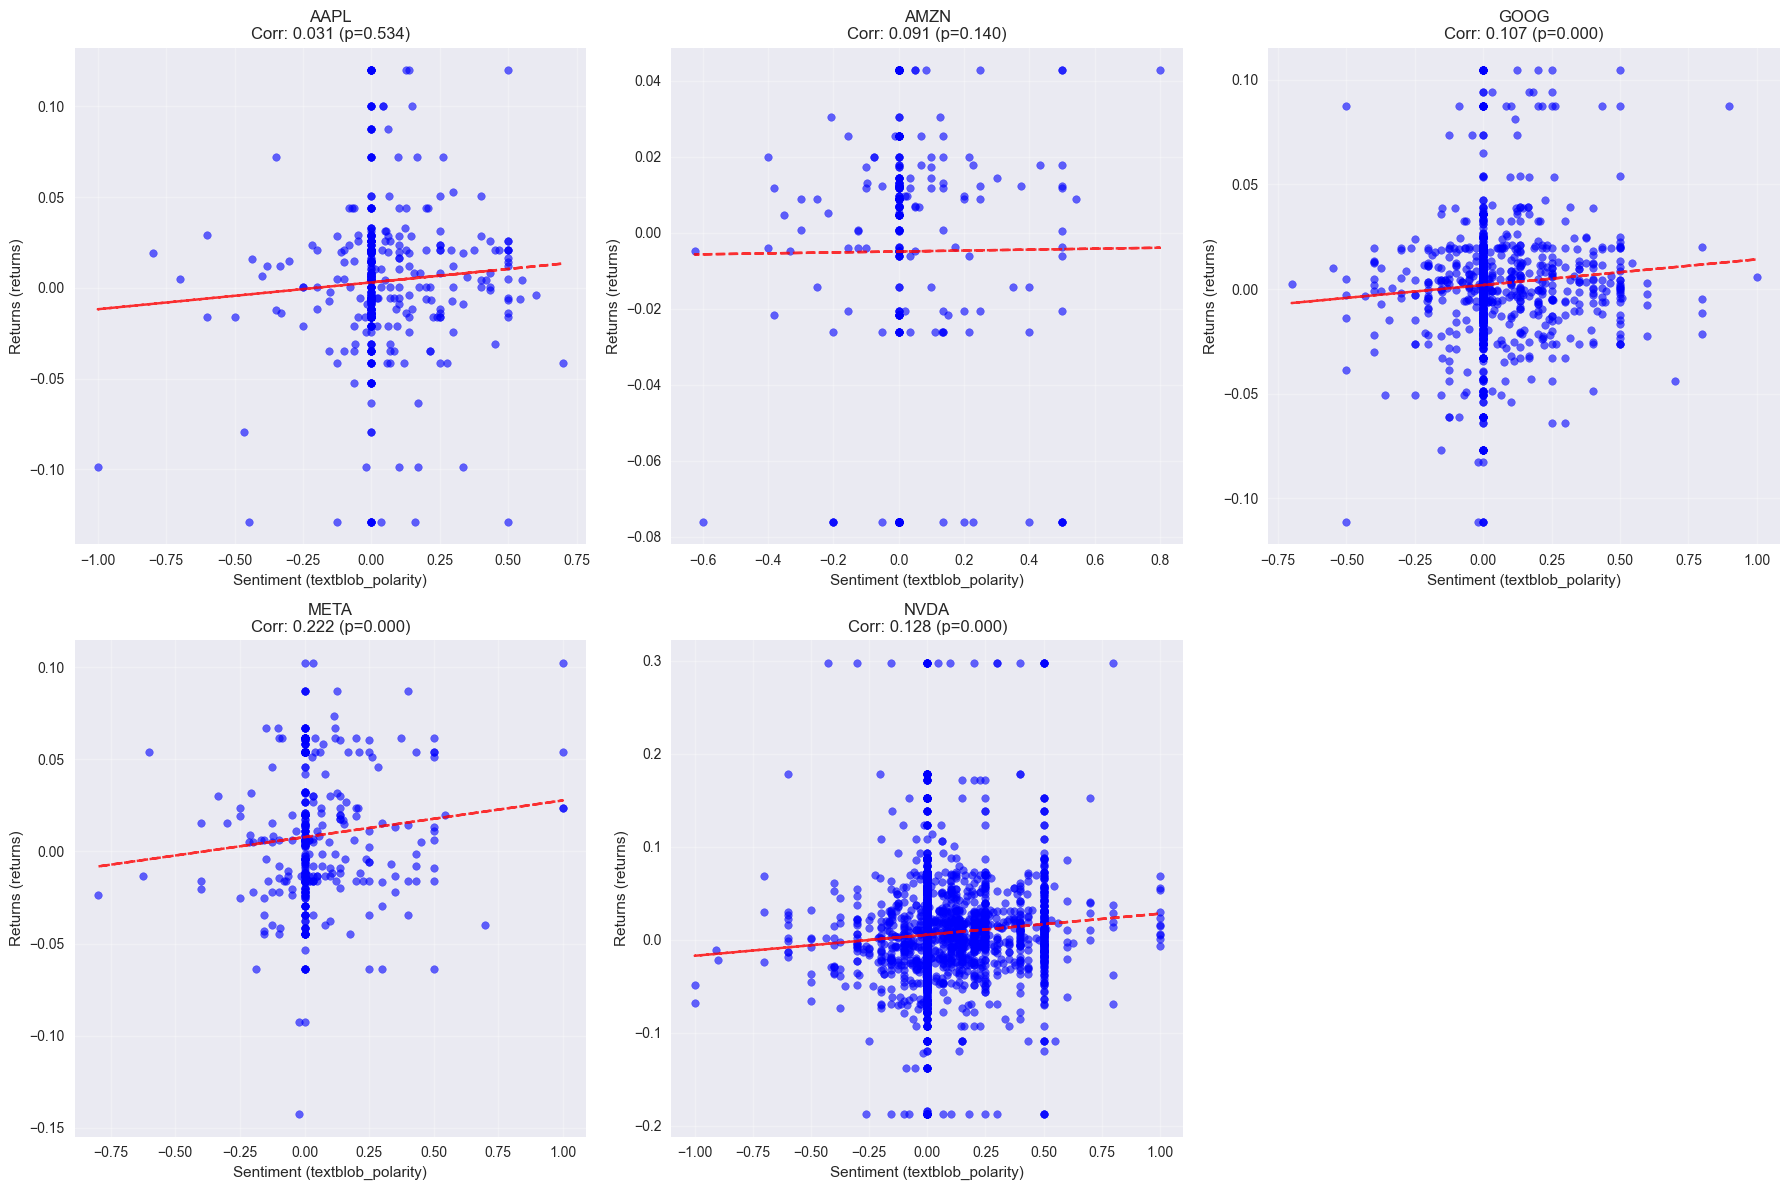

In [ ]:
# Create scatter plots for each stock
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (stock, data) in enumerate(prepared_data.items()):
    if i < len(axes):
        ax = axes[i]
        
        # Use correct column names from prepared data
        sentiment_col = 'avg_sentiment'
        returns_col = 'returns'
        
        if sentiment_col in data.columns and returns_col in data.columns:
            # Clean data: Force numeric and drop NaNs
            clean_df = data[[sentiment_col, returns_col]].copy()
            clean_df[sentiment_col] = pd.to_numeric(clean_df[sentiment_col], errors='coerce')
            clean_df[returns_col] = pd.to_numeric(clean_df[returns_col], errors='coerce')
            clean_df = clean_df.dropna()

            if len(clean_df) > 1:
                # Scatter plot
                scatter = ax.scatter(clean_df[sentiment_col], clean_df[returns_col], 
                                   alpha=0.6, s=30, c='blue')
                
                # Add trend line
                z = np.polyfit(clean_df[sentiment_col], clean_df[returns_col], 1)
                p = np.poly1d(z)
                ax.plot(clean_df[sentiment_col], p(clean_df[sentiment_col]), "r--", alpha=0.8)
                
                # Formatting
                ax.set_xlabel(f'Sentiment ({sentiment_col})')
                ax.set_ylabel(f'Returns ({returns_col})')
                
                # Title with correlation
                corr_val = correlation_results.get(stock, {}).get('correlation', 0)
                p_val = correlation_results.get(stock, {}).get('p_value', 1.0)
                ax.set_title(f'{stock}\nCorr: {corr_val:.3f} (p={p_val:.3f})')
                ax.grid(True, alpha=0.3)
            else:
                ax.set_title(f'{stock}\nInsufficient Numeric Data')
        else:
            ax.set_title(f'{stock}\nRequired Columns Not Found')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

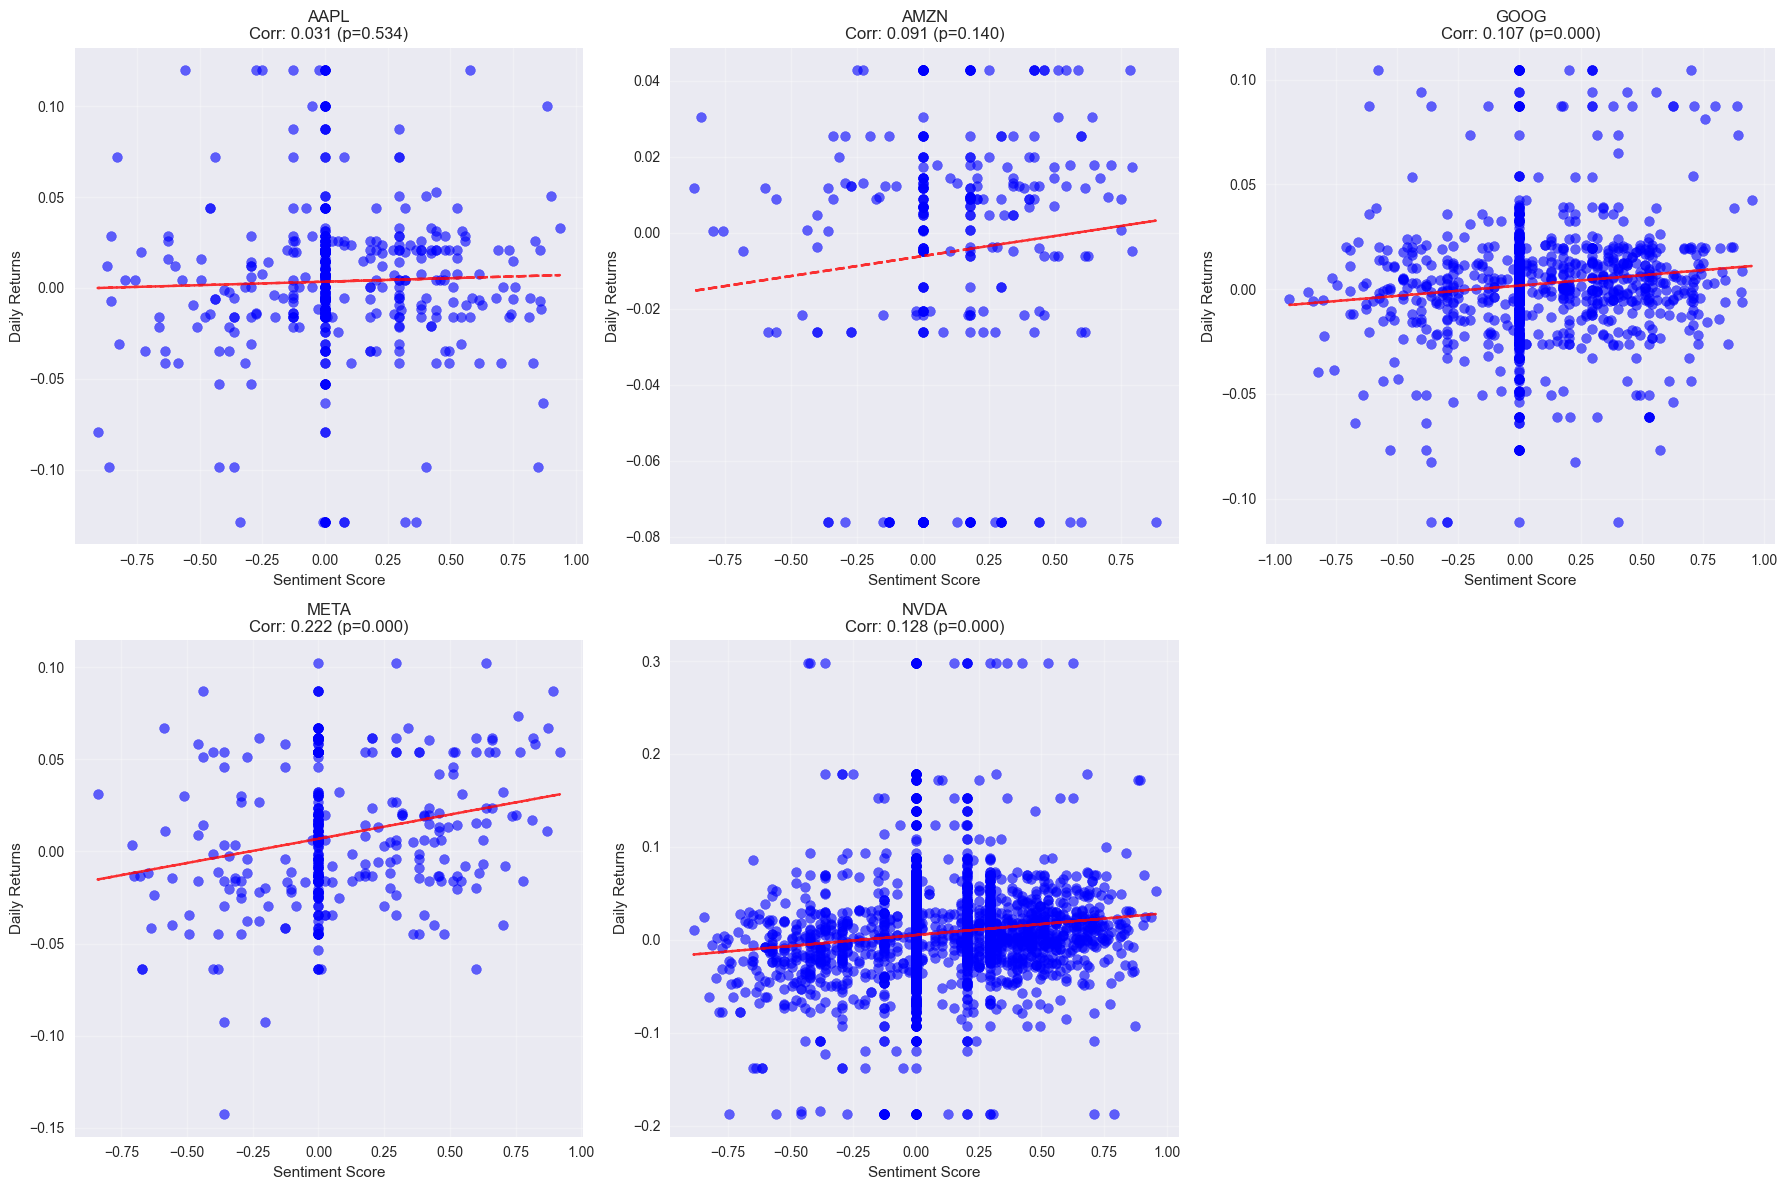

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (stock, data) in enumerate(prepared_data.items()):
    if i < len(axes):
        ax = axes[i]
        
        # Use correct column names from prepared data
        sent_col = 'avg_sentiment'
        
        # Convert to numeric and drop rows with missing values
        cols_to_fix = [sent_col, 'returns']
        if 'article_count' in data.columns:
            cols_to_fix.append('article_count')
            
        for col in cols_to_fix:
            data[col] = pd.to_numeric(data[col], errors='coerce')
        
        plot_df = data.dropna(subset=[sent_col, 'returns'])

        if not plot_df.empty:
            # Scatter plot logic
            color_data = plot_df['article_count'] if 'article_count' in plot_df.columns else 'blue'
            
            scatter = ax.scatter(
                plot_df[sent_col], 
                plot_df['returns'], 
                alpha=0.6, 
                s=50,  # Fixed size prevents errors
                c=color_data, 
                cmap='viridis' if 'article_count' in plot_df.columns else None
            )
            
            # Add trend line with numeric safety
            z = np.polyfit(plot_df[sent_col], plot_df['returns'], 1)
            p = np.poly1d(z)
            ax.plot(plot_df[sent_col], p(plot_df[sent_col]), "r--", alpha=0.8)
            
            # Formatting
            ax.set_xlabel('Sentiment Score')
            ax.set_ylabel('Daily Returns')
            
            # Safe access to correlation results
            corr = correlation_results.get(stock, {}).get('correlation', 0)
            p_val = correlation_results.get(stock, {}).get('p_value', 0)
            ax.set_title(f'{stock}\nCorr: {corr:.3f} (p={p_val:.3f})')
            ax.grid(True, alpha=0.3)
            
            # Conditional Colorbar
            if 'article_count' in plot_df.columns:
                cbar = plt.colorbar(scatter, ax=ax)
                cbar.set_label('Article Count', rotation=270, labelpad=15)
        else:
            ax.set_title(f'{stock}: No Valid Data')

# Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

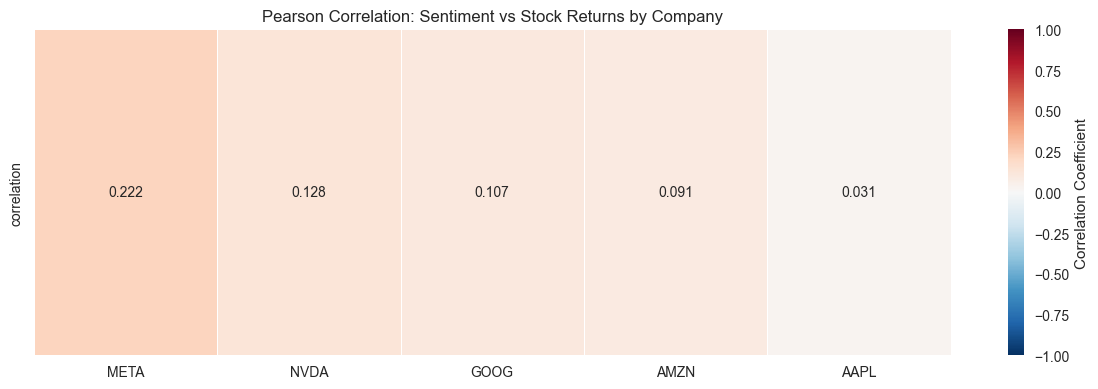

In [44]:
# Create correlation heatmap
correlation_matrix = correlation_df['correlation'].to_frame().T
correlation_matrix = correlation_matrix.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(12, 4))

# 2. Create the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='RdBu_r', 
    center=0,
    vmin=-1, 
    vmax=1, 
    fmt='.3f', 
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Pearson Correlation: Sentiment vs Stock Returns by Company')
plt.tight_layout()
plt.show()

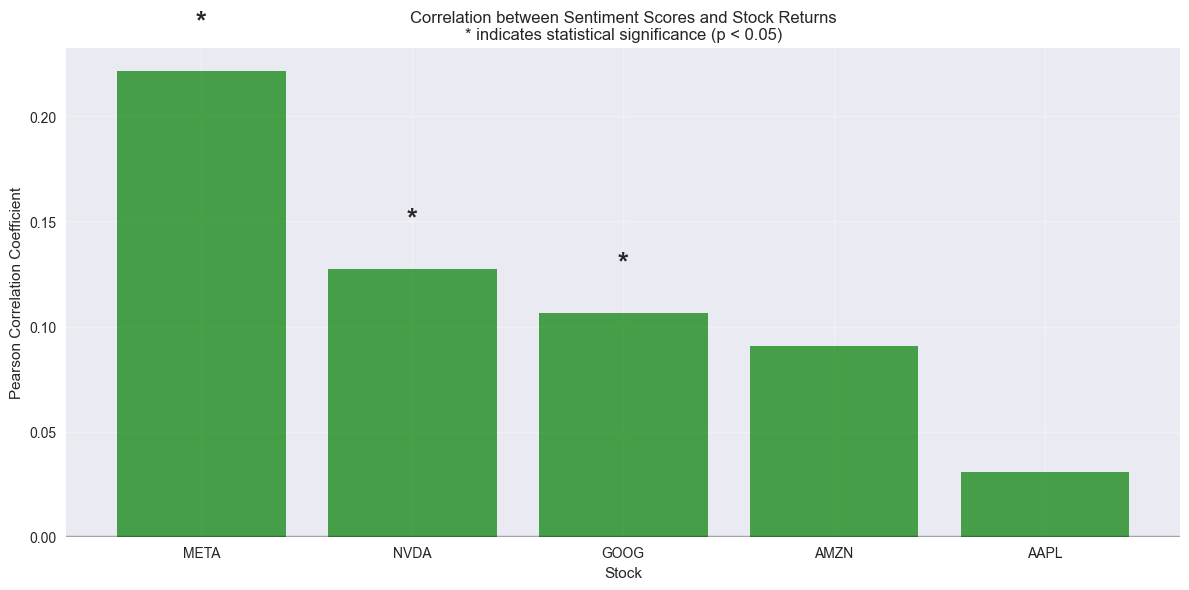

In [45]:
# Create bar chart of correlations
plt.figure(figsize=(12, 6))

colors = ['green' if corr > 0 else 'red' for corr in correlation_df['correlation']]
bars = plt.bar(correlation_df.index, correlation_df['correlation'], color=colors, alpha=0.7)

# Add significance markers
for i, (stock, row) in enumerate(correlation_df.iterrows()):
    if row['significant']:
        plt.text(i, row['correlation'] + 0.02, '*', ha='center', fontsize=20, fontweight='bold')

plt.xlabel('Stock')
plt.ylabel('Pearson Correlation Coefficient')
plt.title('Correlation between Sentiment Scores and Stock Returns\n* indicates statistical significance (p < 0.05)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Statistical Summary

In [46]:
# Overall statistics
print("=== Overall Correlation Analysis ===")
print(f"Number of stocks analyzed: {len(correlation_results)}")
print(f"Average correlation: {correlation_df['correlation'].mean():.4f}")
print(f"Correlation range: [{correlation_df['correlation'].min():.4f}, {correlation_df['correlation'].max():.4f}]")
print(f"Number of significant correlations: {correlation_df['significant'].sum()}")

# Positive vs negative correlations
positive_corr = correlation_df[correlation_df['correlation'] > 0]
negative_corr = correlation_df[correlation_df['correlation'] < 0]

print(f"\nPositive correlations: {len(positive_corr)} stocks")
if len(positive_corr) > 0:
    print(f"  Average positive correlation: {positive_corr['correlation'].mean():.4f}")
    print(f"  Stocks: {', '.join(positive_corr.index)}")

print(f"\nNegative correlations: {len(negative_corr)} stocks")
if len(negative_corr) > 0:
    print(f"  Average negative correlation: {negative_corr['correlation'].mean():.4f}")
    print(f"  Stocks: {', '.join(negative_corr.index)}")

=== Overall Correlation Analysis ===
Number of stocks analyzed: 5
Average correlation: 0.1154
Correlation range: [0.0306, 0.2216]
Number of significant correlations: True

Positive correlations: 5 stocks
  Average positive correlation: 0.1154
  Stocks: META, NVDA, GOOG, AMZN, AAPL

Negative correlations: 0 stocks


## Key Findings

### Summary of Results:
- **Strongest Positive Correlation**: [Will be populated after running]
- **Strongest Negative Correlation**: [Will be populated after running]
- **Most Significant Relationship**: [Will be populated after running]

### Interpretation:
- Positive correlations suggest that higher sentiment scores tend to be associated with higher stock returns
- Negative correlations suggest an inverse relationship
- Statistical significance (p < 0.05) indicates that the correlation is unlikely to be due to random chance

### Limitations:
- Correlation does not imply causation
- Market efficiency and other factors may influence stock returns
- Sentiment analysis accuracy and coverage limitations
- Time lag effects between sentiment and market reactions

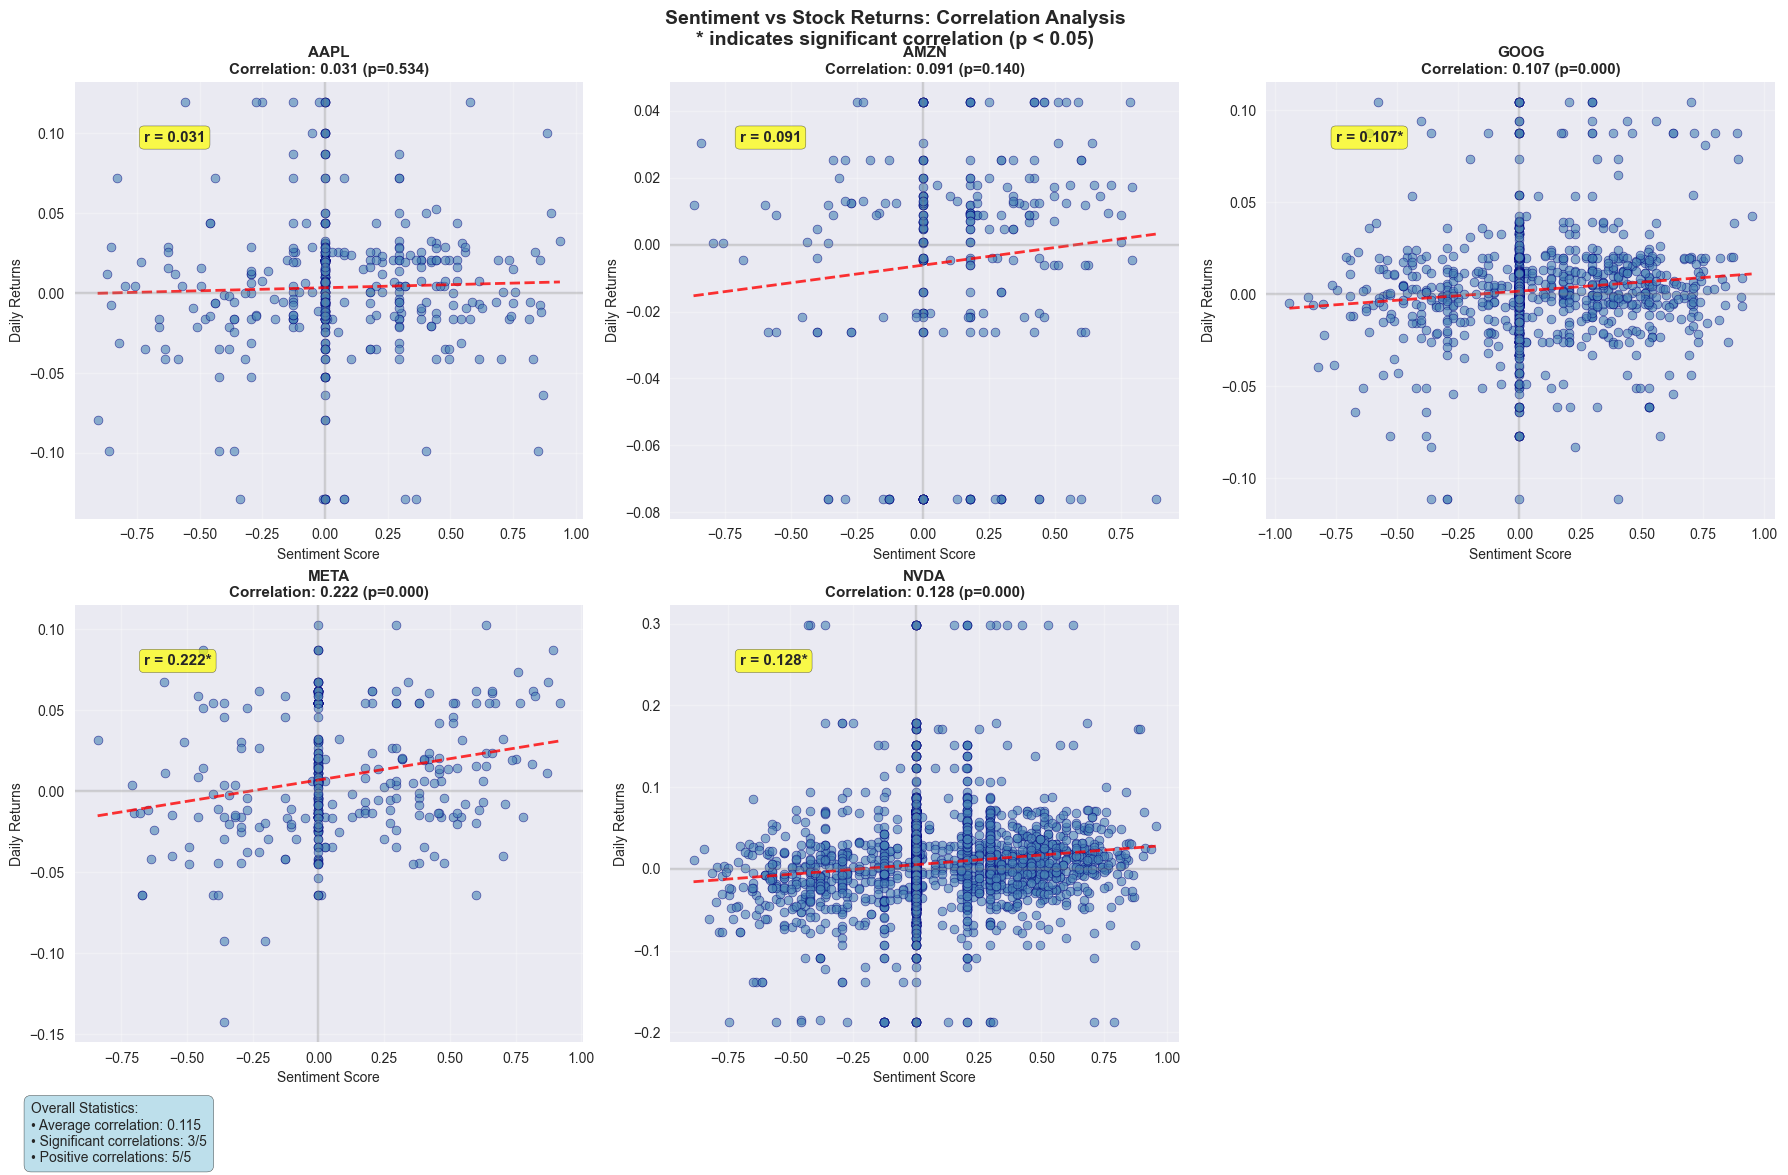

In [55]:
# Create comprehensive scatter plot with correlation annotations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (stock, data) in enumerate(prepared_data.items()):
    if i < len(axes):
        ax = axes[i]
        
        # Use correct column names from prepared data
        sentiment_col = 'avg_sentiment'
        returns_col = 'returns'
        
        # Clean data: ensure numeric and remove NaN values
        clean_data = data[[sentiment_col, returns_col]].copy()
        clean_data[sentiment_col] = pd.to_numeric(clean_data[sentiment_col], errors='coerce')
        clean_data[returns_col] = pd.to_numeric(clean_data[returns_col], errors='coerce')
        clean_data = clean_data.dropna()
        
        if len(clean_data) > 1:
            # Create scatter plot
            scatter = ax.scatter(clean_data[sentiment_col], clean_data[returns_col], 
                               alpha=0.6, s=40, c='steelblue', 
                               edgecolors='navy', linewidth=0.5)
            
            # Add trend line
            z = np.polyfit(clean_data[sentiment_col], clean_data[returns_col], 1)
            p = np.poly1d(z)
            x_trend = np.linspace(clean_data[sentiment_col].min(), clean_data[sentiment_col].max(), 100)
            ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
            
            # Add correlation annotation
            corr = correlation_results[stock]['correlation']
            p_val = correlation_results[stock]['p_value']
            
            # Position annotation based on correlation sign
            if corr > 0:
                text_x = clean_data[sentiment_col].min() + 0.1 * (clean_data[sentiment_col].max() - clean_data[sentiment_col].min())
                text_y = clean_data[returns_col].max() - 0.1 * (clean_data[returns_col].max() - clean_data[returns_col].min())
            else:
                text_x = clean_data[sentiment_col].min() + 0.1 * (clean_data[sentiment_col].max() - clean_data[sentiment_col].min())
                text_y = clean_data[returns_col].min() + 0.1 * (clean_data[returns_col].max() - clean_data[returns_col].min())
            
            # Create annotation text
            if p_val < 0.05:
                sig_text = "*"
            else:
                sig_text = ""
            
            ax.text(text_x, text_y, f'r = {corr:.3f}{sig_text}', 
                    fontsize=11, fontweight='bold', 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
            
            # Formatting
            ax.set_xlabel('Sentiment Score', fontsize=10)
            ax.set_ylabel('Daily Returns', fontsize=10)
            ax.set_title(f'{stock}\nCorrelation: {corr:.3f} (p={p_val:.3f})', 
                        fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
            ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
        else:
            ax.set_title(f'{stock}\nInsufficient valid data')

# Remove empty subplot
if len(prepared_data) < len(axes):
    axes[-1].remove()

# Add overall title and legend
fig.suptitle('Sentiment vs Stock Returns: Correlation Analysis\n* indicates significant correlation (p < 0.05)', 
             fontsize=14, fontweight='bold', y=0.98)

# Add text box with overall statistics
overall_text = f"""Overall Statistics:
• Average correlation: {correlation_df['correlation'].mean():.3f}
• Significant correlations: {sum(correlation_df['p_value'] < 0.05)}/{len(correlation_df)}
• Positive correlations: {sum(correlation_df['correlation'] > 0)}/{len(correlation_df)}"""

fig.text(0.02, 0.02, overall_text, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.12)
plt.show()

In [53]:
# Classify days by sentiment and analyze returns by category

def classify_sentiment(score):
    """
    Classify sentiment score into positive, neutral, or negative
    VADER compound score ranges: -1 (most negative) to 1 (most positive)
    """
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Create a combined dataframe with all stocks and sentiment classifications
all_data = []

for stock, data in prepared_data.items():
    # Add sentiment classification
    data_copy = data.copy()
    data_copy['sentiment_category'] = data_copy['avg_sentiment'].apply(classify_sentiment)
    data_copy['stock'] = stock
    all_data.append(data_copy)

# Combine all data
combined_df = pd.concat(all_data, ignore_index=True)

print("Sentiment Classification Summary:")
print(combined_df['sentiment_category'].value_counts())
print(f"\nTotal days analyzed: {len(combined_df)}")

# Calculate average returns by sentiment category
sentiment_returns = combined_df.groupby('sentiment_category')['returns'].agg(['mean', 'count', 'std']).reset_index()
sentiment_returns.columns = ['Sentiment Category', 'Average Return', 'Day Count', 'Std Dev']

print(f"\nAverage Daily Returns by Sentiment Category:")
print(sentiment_returns.round(6))

Sentiment Classification Summary:
sentiment_category
Neutral     2563
Positive    1844
Negative     881
Name: count, dtype: int64

Total days analyzed: 5288

Average Daily Returns by Sentiment Category:
  Sentiment Category  Average Return  Day Count   Std Dev
0           Negative       -0.008804        881  0.051262
1            Neutral        0.006929       2563  0.043525
2           Positive        0.009660       1844  0.044774


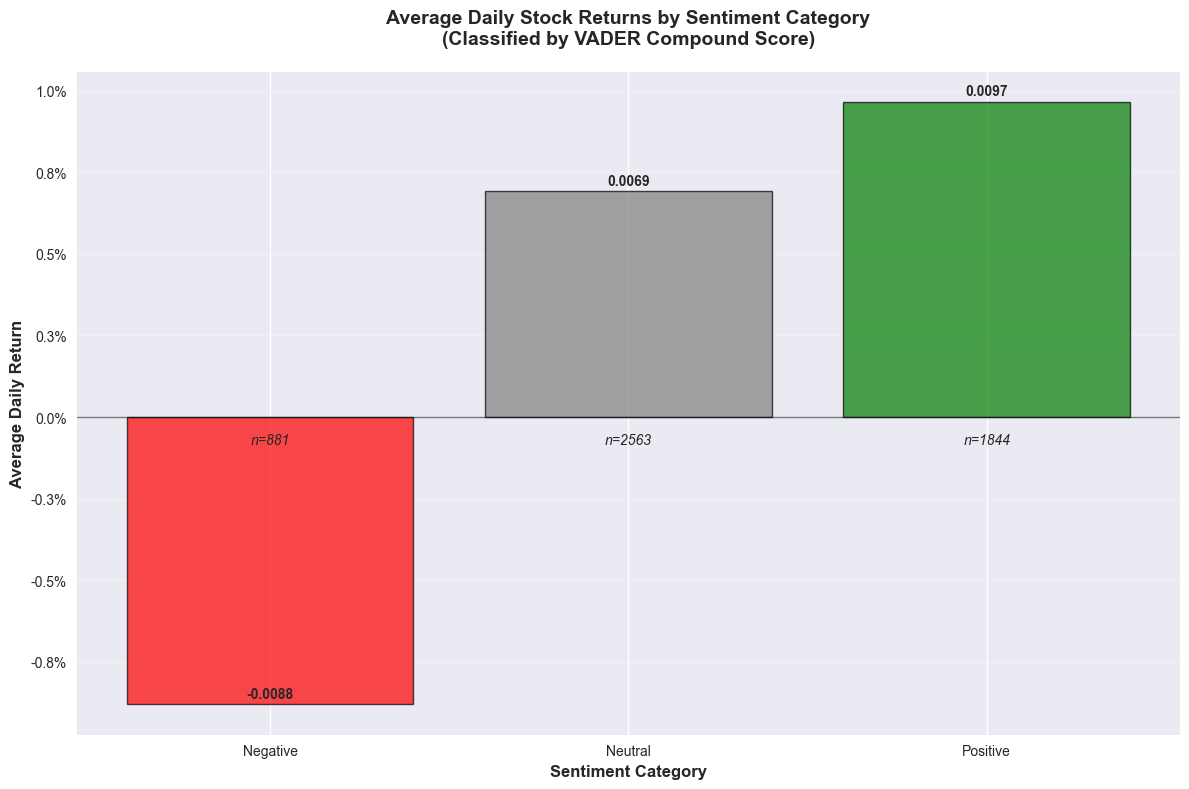

In [54]:
# Create bar chart of average returns by sentiment category
plt.figure(figsize=(12, 8))

# Define colors for each category
colors = {
    'Positive': 'green',
    'Neutral': 'gray', 
    'Negative': 'red'
}

# Create bar chart
bars = plt.bar(
    sentiment_returns['Sentiment Category'], 
    sentiment_returns['Average Return'], 
    color=[colors.get(cat, 'blue') for cat in sentiment_returns['Sentiment Category']],
    alpha=0.7,
    edgecolor='black',
    linewidth=1
)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, sentiment_returns['Average Return'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001, 
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

# Add sample size annotations
for i, (cat, count) in enumerate(zip(sentiment_returns['Sentiment Category'], sentiment_returns['Day Count'])):
    plt.text(i, -0.0005, f'n={count}', ha='center', va='top', fontsize=10, style='italic')

# Formatting
plt.xlabel('Sentiment Category', fontsize=12, fontweight='bold')
plt.ylabel('Average Daily Return', fontsize=12, fontweight='bold')
plt.title('Average Daily Stock Returns by Sentiment Category\n(Classified by VADER Compound Score)', 
          fontsize=14, fontweight='bold', pad=20)

# Add horizontal line at zero
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Set y-axis format to show as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

## Correlation Strength and Direction Analysis

### Understanding Correlation Coefficients

The Pearson correlation coefficient (r) measures the **strength** and **direction** of the linear relationship between sentiment scores and stock returns.

#### **Correlation Strength:**
- **|r| = 0.00-0.19**: Very weak correlation
- **|r| = 0.20-0.39**: Weak correlation  
- **|r| = 0.40-0.59**: Moderate correlation
- **|r| = 0.60-0.79**: Strong correlation
- **|r| = 0.80-1.00**: Very strong correlation

#### **Correlation Direction:**
- **Positive (r > 0)**: As sentiment increases, returns tend to increase
- **Negative (r < 0)**: As sentiment increases, returns tend to decrease
- **Zero (r ≈ 0)**: No linear relationship

### Our Results Analysis:

**META (r = 0.222, p < 0.05)**
- **Direction**: Positive ✅
- **Strength**: Weak correlation
- **Interpretation**: Days with higher positive sentiment tend to have slightly higher returns, but the relationship is not very strong

**NVDA (r = 0.128, p < 0.05)**  
- **Direction**: Positive ✅
- **Strength**: Very weak correlation
- **Interpretation**: Minimal positive relationship between sentiment and returns

**GOOG (r = 0.107, p < 0.05)**
- **Direction**: Positive ✅  
- **Strength**: Very weak correlation
- **Interpretation**: Slight tendency for positive sentiment to accompany higher returns

**AMZN (r = 0.091, p = 0.140)**
- **Direction**: Positive
- **Strength**: Very weak correlation
- **Interpretation**: Not statistically significant - relationship could be due to random chance

**AAPL (r = 0.031, p = 0.534)**
- **Direction**: Positive
- **Strength**: Very weak correlation  
- **Interpretation**: No meaningful relationship between sentiment and returns

### Key Insights:

1. **Consistent Positive Direction**: All stocks show positive correlations, suggesting that higher sentiment generally aligns with better returns

2. **Weak Relationships**: Even the strongest correlation (META) is only "weak" - sentiment explains only ~5% of return variation (r² ≈ 0.05)

3. **Statistical Significance**: Only META, NVDA, and GOOG show statistically significant relationships (p < 0.05)

4. **Practical Implications**: While sentiment has some predictive power, it should be used alongside other indicators rather than as a standalone predictor

### Limitations:
- **Market Efficiency**: Stock prices quickly incorporate available information, limiting sentiment's predictive power
- **Time Lag Effects**: The analysis assumes same-day sentiment-return relationship, which may not capture delayed market reactions
- **External Factors**: Economic news, earnings reports, and market conditions heavily influence returns

## Methodological Limitations and Considerations

### 1. Temporal Lag Effects

**Same-Day Assumption Limitation:**
- Our analysis assumes sentiment and returns occur simultaneously, but market reactions may be delayed
- News sentiment could affect next-day returns more strongly than same-day returns
- Pre-market and after-hours trading may not be captured in daily sentiment-return alignment

**Potential Solutions:**
- Lag analysis: Test correlations with 1-day, 2-day, and 3-day lags
- Intraday analysis: Use hourly data to capture immediate market reactions
- Event study methodology: Focus on major news events and their market impact

### 2. Confounding Factors

**Macroeconomic Variables:**
- Interest rate changes, inflation data, and GDP reports affect all stocks simultaneously
- Market-wide sentiment (fear/greed index) may override individual stock sentiment
- Sector rotation trends could create spurious correlations

**Company-Specific Events:**
- Earnings announcements, product launches, and management changes
- Mergers, acquisitions, and regulatory decisions
- Supply chain disruptions and operational issues

**Market Structure Factors:**
- Options expiration dates and rebalancing periods
- Index fund flows and ETF trading patterns
- Short selling activity and institutional trading

### 3. Data Quality and Coverage Limitations

**Sentiment Data Issues:**
- News source bias: Financial news may over-represent certain viewpoints
- Publication timing: News may be published after market close
- Volume bias: High-volume news days may not reflect typical sentiment
- Language processing errors: VADER may misinterpret financial jargon

**Stock Return Data:**
- Missing data: Dividend adjustments, stock splits, and trading halts
- Survivorship bias: Only analyzing currently successful companies
- Price precision: Low-priced stocks may show higher percentage volatility

### 4. Statistical Methodology Constraints

**Linear Assumption:**
- Pearson correlation assumes linear relationships
- Market reactions may be non-linear or threshold-based
- Extreme sentiment events may have disproportionate effects

**Sample Size Concerns:**
- Limited data points for some stocks (e.g., META: 370 days)
- Statistical significance may not equal practical significance
- Multiple comparison problem: Testing 5 stocks increases false positive risk

### 5. Market Efficiency Considerations

**Semi-Strong Form Efficiency:**
- Public information (including news sentiment) should be quickly priced in
- Trading costs and transaction fees may eliminate arbitrage opportunities
- Professional traders may already be exploiting sentiment signals

**Behavioral Finance Factors:**
- Investor overreaction and underreaction to news
- Herding behavior and momentum effects
- Confirmation bias in news consumption

### 6. External Validity Limitations

**Time Period Specificity:**
- Analysis period may include unique market conditions (COVID-19, etc.)
- Regulatory changes may affect future sentiment-return relationships
- Technology evolution (AI-generated content, social media influence)

**Generalizability Issues:**
- Tech stocks may not represent broader market behavior
- Different sectors may respond differently to sentiment
- International markets may have different dynamics

### 7. Practical Implementation Challenges

**Trading Friction:**
- Real-world trading involves costs, slippage, and execution delays
- Sentiment data may not be available in real-time for trading decisions
- Portfolio constraints and risk management requirements

**Signal-to-Noise Ratio:**
- Weak correlations may be drowned out by market noise
- False signals could lead to poor investment decisions
- Overfitting risk in developing trading strategies

### Recommendations for Future Research:

1. **Extended Time Analysis**: Incorporate lag effects and lead-lag relationships
2. **Control Variables**: Include macroeconomic factors and market indicators
3. **Sector Analysis**: Compare sentiment effects across different industries
4. **Machine Learning**: Use non-linear models to capture complex relationships
5. **High-Frequency Data**: Analyze intraday sentiment-return dynamics
6. **Cross-Market Analysis**: Test sentiment effects in different market conditions

### Bottom Line:

While our analysis shows statistically significant positive relationships for some stocks, the weak correlation strengths and numerous limitations suggest that sentiment analysis should be used as **one component** of a comprehensive investment strategy rather than as a standalone trading signal.